# Accelerometer and EMG extraction exploration

## Package imports and data import

In [1]:
import json
import numpy as np
import pandas as pd

# -----------------------------
# Inputs
# -----------------------------
csv_path = "Jessie_Trial_Cole_-_Muscle_Response_April_24_Rep_1.0.csv"
json_path = "experiment_log.json"

# IMPORTANT:
# Set this to the column in your EMG CSV that contains seconds elapsed.
# You previously used df.iloc[:, 1], so this assumes the SECOND column.
seconds_col_index = 0

# This is the real EMG recording start time.
csv_start_time = "11:46:23 AM"

# -----------------------------
# Load EMG CSV
# -----------------------------
df = pd.read_csv(csv_path, low_memory=False)

# Get elapsed seconds from EMG dataframe
emg_seconds = pd.to_numeric(df.iloc[:, seconds_col_index], errors="coerce").to_numpy()

# -----------------------------
# Load experiment JSON
# -----------------------------
with open(json_path, "r") as f:
    log = json.load(f)

# Use the JSON date, but the EMG/CSV start time
experiment_date = pd.to_datetime(log["start_time"]).date()
csv_start_datetime = pd.to_datetime(f"{experiment_date} {csv_start_time}")

# -----------------------------
# Build event table from JSON logs
# -----------------------------
event_rows = []

for trial in log["trial_logs"]:
    condition = trial["condition"]

    electrode_config = condition["electrode_config"]
    waveform = condition["waveform"]
    polarity = condition["polarity"]

    config = f"{electrode_config} | {waveform} | {polarity}"

    for report in trial["patient_reports"]:
        report_time = pd.to_datetime(report["current_time"])

        # Convert JSON log time into seconds after EMG/CSV start
        report_seconds_after_csv_start = (
            report_time - csv_start_datetime
        ).total_seconds()

        event_rows.append({
            "event_time": report_time,
            "event_seconds": report_seconds_after_csv_start,
            "config": config,
            "current_intensity_ma": float(report["current_intensity_ma"]),
        })

events_df = (
    pd.DataFrame(event_rows)
    .sort_values("event_seconds")
    .reset_index(drop=True)
)

# Optional but useful diagnostic
print(events_df)


# -----------------------------
# Match each EMG row to latest prior JSON event
# -----------------------------
event_seconds = events_df["event_seconds"].to_numpy(dtype=float)

# For each EMG timestamp, find the most recent event at or before that time
event_idx = np.searchsorted(event_seconds, emg_seconds, side="right") - 1

print(event_idx)


                   event_time  event_seconds                  config  \
0  2026-04-24 11:51:06.849790     283.849790  DV-I | Active | Normal   
1  2026-04-24 11:55:44.617944     561.617944  DV-I | Active | Normal   
2  2026-04-24 11:57:14.402380     651.402380  DV-I | Active | Normal   
3  2026-04-24 11:59:23.116680     780.116680  DV-I | Active | Normal   
4  2026-04-24 12:06:47.522008    1224.522008  DV-I | Active | Normal   
5  2026-04-24 12:09:46.310403    1403.310403  DV-I | Active | Normal   
6  2026-04-24 12:12:20.781260    1557.781260  DV-I | Active | Normal   
7  2026-04-24 12:13:28.983967    1625.983967  DV-I | Active | Normal   
8  2026-04-24 12:15:23.595798    1740.595798  DV-I | Active | Normal   
9  2026-04-24 12:22:14.122012    2151.122012  DV-I | Active | Normal   
10 2026-04-24 12:24:57.856875    2314.856875  DV-I | Active | Normal   

    current_intensity_ma  
0                    5.0  
1                   15.0  
2                   15.0  
3                   21.0  


In [3]:
df.shape

(5124000, 32)

In [4]:
# Rows before the first event get -1
valid = event_idx >= 0

# -----------------------------
# Match each EMG row to latest prior JSON event
# -----------------------------
event_seconds = events_df["event_seconds"].to_numpy(dtype=float)

# For each EMG timestamp, find the most recent event at or before that time
event_idx = np.searchsorted(event_seconds, emg_seconds, side="right") - 1

# print(event_idx[100000:100100])

# Rows before the first event get -1
valid = event_idx >= 0

# -----------------------------
# Create only the two new columns
# -----------------------------
config_col = np.full(len(df), pd.NA, dtype=object)
current_col = np.full(len(df), np.nan, dtype=float)

config_values = events_df["config"].to_numpy(dtype=object)
current_values = events_df["current_intensity_ma"].to_numpy(dtype=float)

config_col[valid] = config_values[event_idx[valid]]
current_col[valid] = current_values[event_idx[valid]]

# -----------------------------
# Insert at the left of EMG dataframe
# -----------------------------
df.insert(0, "config", pd.Categorical(config_col))
df.insert(1, "current_intensity_ma", current_col)

# -----------------------------
# Check result
# -----------------------------
print(df[["config", "current_intensity_ma"]].value_counts(dropna=False))
df.head(30)

config                  current_intensity_ma
DV-I | Active | Normal  21.0                    888812
                        36.0                    821053
NaN                     NaN                     567700
DV-I | Active | Normal  5.0                     555536
                        40.0                    494286
                        15.0                    436998
                        31.0                    357575
                        38.0                    327469
                        33.0                    308943
                        32.0                    229225
                        29.5                    136403
Name: count, dtype: int64


,config,current_intensity_ma,X[s],L VASTUS LATERALIS: EMG 1,X[s].1,L VASTUS LATERALIS: ACC.X 1,X[s].2,L VASTUS LATERALIS: ACC.Y 1,X[s].3,L VASTUS LATERALIS: ACC.Z 1,...,X[s].11,R VASTUS LATERALIS: ACC.Z 3,X[s].12,R VASTUS MEDIALIS: EMG 4,X[s].13,R VASTUS MEDIALIS: ACC.X 4,X[s].14,R VASTUS MEDIALIS: ACC.Y 4,X[s].15,R VASTUS MEDIALIS: ACC.Z 4
0,NaN,NaN,0.0000,0.0,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.0000,0.0,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000
1,NaN,NaN,0.0005,0.0,0.00675,0.000000,0.00675,0.000000,0.00675,0.000000,...,0.00675,0.000000,0.0005,0.0,0.00675,0.000000,0.00675,0.000000,0.00675,0.000000
2,NaN,NaN,0.0010,0.0,0.01350,0.000000,0.01350,0.000000,0.01350,0.000000,...,0.01350,0.000000,0.0010,0.0,0.01350,0.000000,0.01350,0.000000,0.01350,0.000000
3,NaN,NaN,0.0015,0.0,0.02025,0.000000,0.02025,0.000000,0.02025,0.000000,...,0.02025,0.000000,0.0015,0.0,0.02025,0.000000,0.02025,0.000000,0.02025,0.000000
4,NaN,NaN,0.0020,0.0,0.02700,0.000000,0.02700,0.000000,0.02700,0.000000,...,0.02700,0.000000,0.0020,0.0,0.02700,0.000000,0.02700,0.000000,0.02700,0.000000
5,NaN,NaN,0.0025,0.0,0.03375,0.000000,0.03375,0.000000,0.03375,0.000000,...,0.03375,0.000000,0.0025,0.0,0.03375,0.000000,0.03375,0.000000,0.03375,0.000000
6,NaN,NaN,0.0030,0.0,0.04050,0.000000,0.04050,0.000000,0.04050,0.000000,...,0.04050,0.000000,0.0030,0.0,0.04050,0.000000,0.04050,0.000000,0.04050,0.000000
7,NaN,NaN,0.0035,0.0,0.04725,0.000000,0.04725,0.000000,0.04725,0.000000,...,0.04725,0.000000,0.0035,0.0,0.04725,0.000000,0.04725,0.000000,0.04725,0.000000
8,NaN,NaN,0.0040,0.0,0.05400,0.000000,0.05400,0.000000,0.05400,0.000000,...,0.05400,0.000000,0.0040,0.0,0.05400,0.000000,0.05400,0.000000,0.05400,0.000000
9,NaN,NaN,0.0045,0.0,0.06075,0.000000,0.06075,0.000000,0.06075,0.000000,...,0.06075,0.000000,0.0045,0.0,0.06075,0.000000,0.06075,0.000000,0.06075,0.000000


## Sample magnitude calculation

In [6]:
random_row = df.sample(n=1).iloc[0]

sensor_columns = {
    "L VASTUS LATERALIS": [
        "L VASTUS LATERALIS: ACC.X 1",
        "L VASTUS LATERALIS: ACC.Y 1",
        "L VASTUS LATERALIS: ACC.Z 1",
    ],
    "L VASTUS MEDIALIS": [
        "L VASTUS MEDIALIS: ACC.X 2",
        "L VASTUS MEDIALIS: ACC.Y 2",
        "L VASTUS MEDIALIS: ACC.Z 2",
    ],
    "R VASTUS LATERALIS": [
        "R VASTUS LATERALIS: ACC.X 3",
        "R VASTUS LATERALIS: ACC.Y 3",
        "R VASTUS LATERALIS: ACC.Z 3",
    ],
    "R VASTUS MEDIALIS": [
        "R VASTUS MEDIALIS: ACC.X 4",
        "R VASTUS MEDIALIS: ACC.Y 4",
        "R VASTUS MEDIALIS: ACC.Z 4",
    ],
}

print(f"Random row index: {random_row.name}")

for sensor_name, columns in sensor_columns.items():
    x, y, z = random_row[columns].astype(float)
    print(x,y,z)
    magnitude = np.sqrt(x**2 + y**2 + z**2)
    print(f"{sensor_name}: {magnitude}")

Random row index: 50391
0.9063859 -0.4149233 0.2417029
L VASTUS LATERALIS: 1.0257275644488208
-0.6364843 -0.1893339 0.7170519
L VASTUS MEDIALIS: 0.9773039532966752
-0.8943008 -0.3424124 0.3464408
R VASTUS LATERALIS: 1.018352296830051
0.7653925 -0.2135042 0.5760586
R VASTUS MEDIALIS: 0.9814546515799139


## Accelerometer Preprocessing

In [7]:
from scipy.signal import butter, filtfilt

acc_time_seconds = pd.to_numeric(df["X[s].1"], errors="coerce")
valid_acc_time = acc_time_seconds.notna()
acc_time_valid = acc_time_seconds[valid_acc_time]

acc_sample_interval = acc_time_valid.diff().dropna().median()
fs_acc = 1 / acc_sample_interval
highpass_cutoff_hz = 0.25

def highpass_acc_axis(values, fs, cutoff_hz=0.25, order=4):
    values = pd.to_numeric(values, errors="coerce")
    values = values.interpolate(limit_direction="both")

    nyquist = fs / 2
    b, a = butter(order, cutoff_hz / nyquist, btype="highpass")
    return filtfilt(b, a, values.to_numpy(dtype=float))

acc_event_idx = np.searchsorted(
    events_df["event_seconds"].to_numpy(dtype=float),
    acc_time_valid.to_numpy(dtype=float),
    side="right",
) - 1
valid_acc_event = acc_event_idx >= 0

acc_config = pd.Series(pd.NA, index=acc_time_seconds.index, dtype=object)
acc_current = pd.Series(np.nan, index=acc_time_seconds.index, dtype=float)
valid_acc_indices = acc_time_valid.index[valid_acc_event]

acc_config.loc[valid_acc_indices] = events_df["config"].to_numpy(dtype=object)[acc_event_idx[valid_acc_event]]
acc_current.loc[valid_acc_indices] = events_df["current_intensity_ma"].to_numpy(dtype=float)[acc_event_idx[valid_acc_event]]

magnitude_by_second = pd.DataFrame({
    "acc_time_seconds": acc_time_seconds,
    "second": np.floor(acc_time_seconds).astype("Int64"),
    "config": acc_config,
    "current_intensity_ma": acc_current,
})

for sensor_name, columns in sensor_columns.items():
    sensor_values = df.loc[valid_acc_time, columns]
    corrected_axes = [
        highpass_acc_axis(sensor_values[column], fs_acc, highpass_cutoff_hz)
        for column in columns
    ]

    corrected_magnitude = np.sqrt(
        corrected_axes[0]**2
        + corrected_axes[1]**2
        + corrected_axes[2]**2
    )
    magnitude_by_second.loc[valid_acc_time, f"{sensor_name} corrected magnitude"] = corrected_magnitude

magnitude_columns = [column for column in magnitude_by_second.columns if column.endswith(" corrected magnitude")]

def last_non_null(values):
    values = values.dropna()
    return values.iloc[-1] if len(values) else pd.NA

mean_magnitude_by_second_df = (
    magnitude_by_second
    .dropna(subset=["acc_time_seconds"])
    .groupby("second", dropna=False, sort=True)
    .agg({
        "acc_time_seconds": "mean",
        "config": last_non_null,
        "current_intensity_ma": last_non_null,
        **{column: "mean" for column in magnitude_columns},
    })
    .reset_index()
)

mean_magnitude_by_second_df

,second,acc_time_seconds,config,current_intensity_ma,L VASTUS LATERALIS corrected magnitude,L VASTUS MEDIALIS corrected magnitude,R VASTUS LATERALIS corrected magnitude,R VASTUS MEDIALIS corrected magnitude
0,0,0.499500,<NA>,<NA>,0.312363,0.296429,0.308992,0.297242
1,1,1.501875,<NA>,<NA>,0.045885,0.043665,0.045147,0.043441
2,2,2.500875,<NA>,<NA>,0.052498,0.049739,0.051491,0.049905
3,3,3.499875,<NA>,<NA>,0.012233,0.011471,0.012094,0.011896
4,4,4.498875,<NA>,<NA>,0.016410,0.015896,0.016495,0.015841
...,...,...,...,...,...,...,...,...
2557,2557,2557.497372,DV-I | Active | Normal,40.0,0.015202,0.013982,0.014561,0.014216
2558,2558,2558.499765,DV-I | Active | Normal,40.0,0.024527,0.024309,0.016724,0.016179
2559,2559,2559.502135,DV-I | Active | Normal,40.0,0.031421,0.025991,0.028203,0.025993
2560,2560,2560.501142,DV-I | Active | Normal,40.0,0.053379,0.043229,0.036490,0.034460


## Unsmooth Accelerometer Plotting

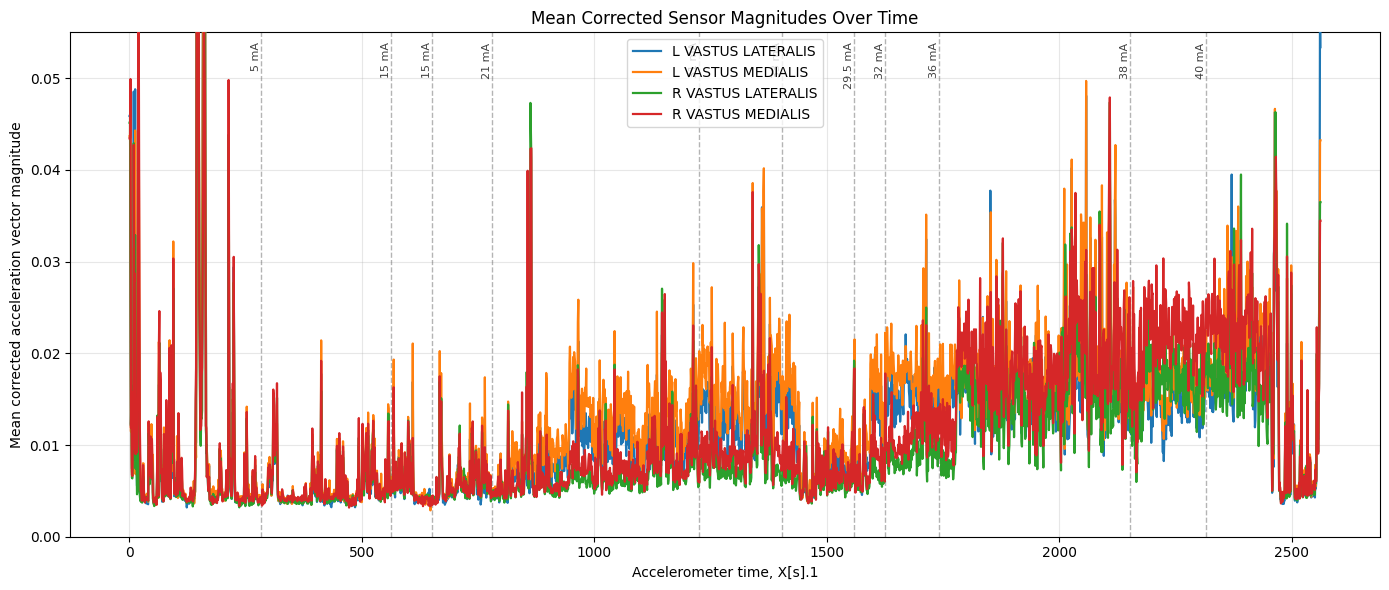

In [8]:
# Plotting cell

import matplotlib.pyplot as plt


magnitude_columns = [
    column
    for column in mean_magnitude_by_second_df.columns
    if column.endswith(" corrected magnitude")
]

outlier_threshold = 0.05
plot_df = mean_magnitude_by_second_df.copy()

def replace_outliers_with_neighbor_mean(values, threshold):
    cleaned = values.astype(float).copy()
    original = cleaned.copy()

    for i in range(len(cleaned)):
        if pd.isna(original.iloc[i]) or original.iloc[i] <= threshold:
            continue

        if i == 0 and len(cleaned) > 1:
            cleaned.iloc[i] = original.iloc[i + 1]
        elif i == len(cleaned) - 1 and len(cleaned) > 1:
            cleaned.iloc[i] = original.iloc[i - 1]
        elif len(cleaned) > 2:
            cleaned.iloc[i] = (original.iloc[i - 1] + original.iloc[i + 1]) / 2

    return cleaned

for column in magnitude_columns:
    plot_df[column] = replace_outliers_with_neighbor_mean(
        plot_df[column],
        outlier_threshold,
    )

plt.figure(figsize=(14, 6))

for column in magnitude_columns:
    plt.plot(
        plot_df["acc_time_seconds"],
        plot_df[column],
        label=column.replace(" corrected magnitude", ""),
        linewidth=1.6,
        zorder=3,
    )

time_min = mean_magnitude_by_second_df["acc_time_seconds"].min()
time_max = mean_magnitude_by_second_df["acc_time_seconds"].max()
event_markers = events_df.dropna(subset=["event_seconds", "current_intensity_ma"])
event_markers = event_markers[
    event_markers["event_seconds"].between(time_min, time_max)
]

for _, event in event_markers.iterrows():
    event_time = event["event_seconds"]
    current_intensity = float(event["current_intensity_ma"])
    plt.axvline(event_time, color="0.35", linestyle="--", linewidth=1, alpha=0.45)
    plt.text(
        event_time,
        0.98,
        f"{current_intensity:g} mA",
        rotation=90,
        transform=plt.gca().get_xaxis_transform(),
        va="top",
        ha="right",
        fontsize=8,
        color="0.25",
    )

plt.xlabel("Accelerometer time, X[s].1")
plt.ylabel("Mean corrected acceleration vector magnitude")
plt.title("Mean Corrected Sensor Magnitudes Over Time")
plt.ylim(bottom=0, top=outlier_threshold * 1.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mean_corrected_sensor_magnitudes.png", dpi=300, bbox_inches="tight")
plt.show()

## Smoothed Accelerometer Plotting

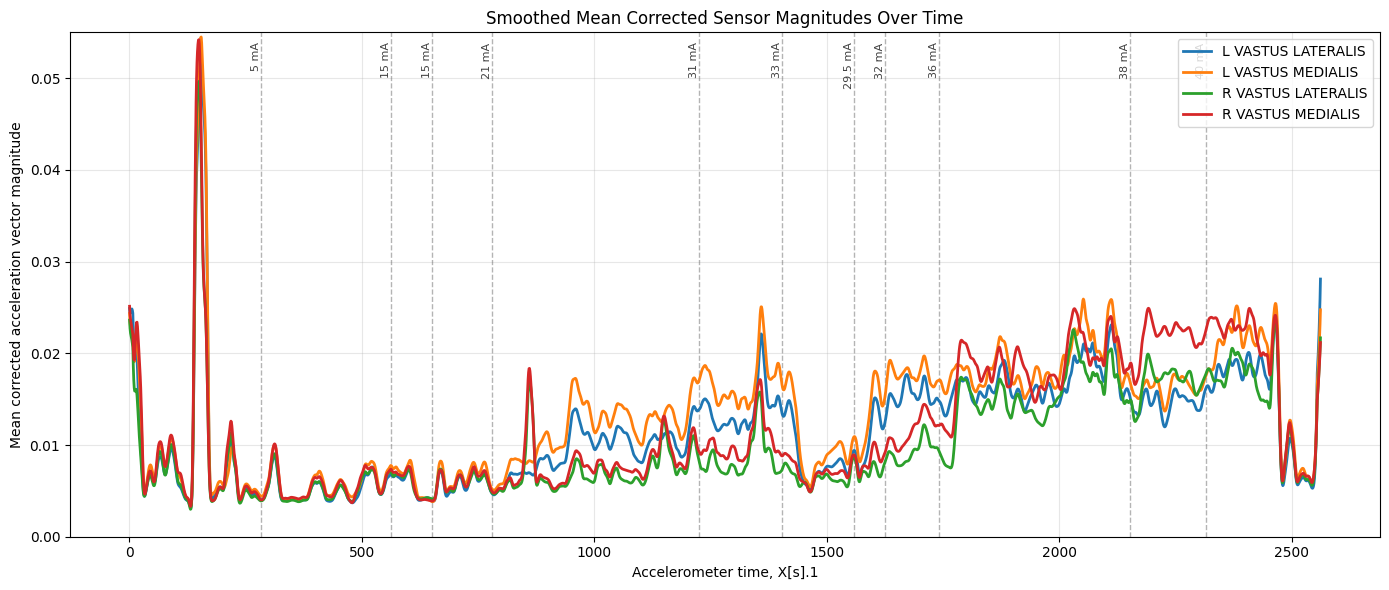

In [9]:
# Smoothed plotting cell

import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

magnitude_columns = [
    column
    for column in mean_magnitude_by_second_df.columns
    if column.endswith(" corrected magnitude")
]

outlier_threshold = 0.05
lowpass_cutoff_hz = 0.08
moving_average_window_seconds = 15
smoothed_plot_df = mean_magnitude_by_second_df.copy()

def replace_outliers_with_neighbor_mean(values, threshold):
    cleaned = values.astype(float).copy()
    original = cleaned.copy()

    for i in range(len(cleaned)):
        if pd.isna(original.iloc[i]) or original.iloc[i] <= threshold:
            continue

        if i == 0 and len(cleaned) > 1:
            cleaned.iloc[i] = original.iloc[i + 1]
        elif i == len(cleaned) - 1 and len(cleaned) > 1:
            cleaned.iloc[i] = original.iloc[i - 1]
        elif len(cleaned) > 2:
            cleaned.iloc[i] = (original.iloc[i - 1] + original.iloc[i + 1]) / 2

    return cleaned

def lowpass_series(values, sample_rate_hz, cutoff_hz, order=2):
    values = values.astype(float).interpolate(limit_direction="both")
    nyquist = sample_rate_hz / 2
    normalized_cutoff = cutoff_hz / nyquist
    b, a = butter(order, normalized_cutoff, btype="lowpass")
    return pd.Series(filtfilt(b, a, values.to_numpy()), index=values.index)

time_step_seconds = smoothed_plot_df["acc_time_seconds"].diff().dropna().median()
sample_rate_hz = 1 / time_step_seconds
moving_average_window = max(3, int(round(moving_average_window_seconds / time_step_seconds)))

for column in magnitude_columns:
    cleaned = replace_outliers_with_neighbor_mean(
        smoothed_plot_df[column],
        outlier_threshold,
    )
    lowpassed = lowpass_series(cleaned, sample_rate_hz, lowpass_cutoff_hz)
    smoothed_plot_df[column] = lowpassed.rolling(
        window=moving_average_window,
        center=True,
        min_periods=1,
    ).mean()

plt.figure(figsize=(14, 6))

for column in magnitude_columns:
    plt.plot(
        smoothed_plot_df["acc_time_seconds"],
        smoothed_plot_df[column],
        label=column.replace(" corrected magnitude", ""),
        linewidth=2.0,
        zorder=3,
    )

time_min = smoothed_plot_df["acc_time_seconds"].min()
time_max = smoothed_plot_df["acc_time_seconds"].max()
event_markers = events_df.dropna(subset=["event_seconds", "current_intensity_ma"])
event_markers = event_markers[
    event_markers["event_seconds"].between(time_min, time_max)
]

for _, event in event_markers.iterrows():
    event_time = event["event_seconds"]
    current_intensity = float(event["current_intensity_ma"])
    plt.axvline(event_time, color="0.35", linestyle="--", linewidth=1, alpha=0.45)
    plt.text(
        event_time,
        0.98,
        f"{current_intensity:g} mA",
        rotation=90,
        transform=plt.gca().get_xaxis_transform(),
        va="top",
        ha="right",
        fontsize=8,
        color="0.25",
    )

plt.xlabel("Accelerometer time, X[s].1")
plt.ylabel("Mean corrected acceleration vector magnitude")
plt.title("Smoothed Mean Corrected Sensor Magnitudes Over Time")
plt.ylim(bottom=0, top=outlier_threshold * 1.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("smoothed_mean_corrected_sensor_magnitudes.png", dpi=300, bbox_inches="tight")
plt.show()

## EMG Sensor Preprocessing

In [2]:
from scipy.signal import butter, filtfilt, iirnotch

emg_channels = {
    "L VASTUS LATERALIS": {
        "time": "X[s]",
        "signal": "L VASTUS LATERALIS: EMG 1",
    },
    "L VASTUS MEDIALIS": {
        "time": "X[s].4",
        "signal": "L VASTUS MEDIALIS: EMG 2",
    },
    "R VASTUS LATERALIS": {
        "time": "X[s].8",
        "signal": "R VASTUS LATERALIS: EMG 3",
    },
    "R VASTUS MEDIALIS": {
        "time": "X[s].12",
        "signal": "R VASTUS MEDIALIS: EMG 4",
    },
}

emg_bandpass_low_hz = 20
emg_bandpass_high_hz = 450
emg_notch_base_hz = 60
emg_notch_quality = 30
emg_rms_window_seconds = 0.1
emg_output_bin_seconds = 0.1

def estimate_sample_rate_hz(time_values):
    time_values = pd.to_numeric(time_values, errors="coerce").dropna()
    time_step = time_values.diff().dropna()
    time_step = time_step[time_step > 0].median()
    return 1 / time_step

def bandpass_filter(values, fs, low_hz, high_hz, order=4):
    nyquist = fs / 2
    high_hz = min(high_hz, nyquist * 0.95)
    b, a = butter(order, [low_hz / nyquist, high_hz / nyquist], btype="bandpass")
    return filtfilt(b, a, values)

def notch_filter_harmonics(values, fs, base_hz=60, quality=30, max_hz=None):
    filtered = values.copy()
    max_hz = fs / 2 if max_hz is None else min(max_hz, fs / 2)
    frequency = base_hz
    while frequency < max_hz:
        b, a = iirnotch(frequency, quality, fs=fs)
        filtered = filtfilt(b, a, filtered)
        frequency += base_hz
    return filtered

def rms_envelope(values, fs, window_seconds):
    window_samples = max(1, int(round(window_seconds * fs)))
    squared = pd.Series(values**2)
    return np.sqrt(
        squared.rolling(
            window=window_samples,
            center=True,
            min_periods=1,
        ).mean()
    ).to_numpy()

emg_time_seconds = pd.to_numeric(df["X[s]"], errors="coerce")
valid_emg_time = emg_time_seconds.notna()
emg_fs = estimate_sample_rate_hz(emg_time_seconds[valid_emg_time])

emg_preprocessed_full = pd.DataFrame({
    "emg_time_seconds": emg_time_seconds[valid_emg_time],
})

for sensor_name, columns in emg_channels.items():
    raw_emg = pd.to_numeric(df.loc[valid_emg_time, columns["signal"]], errors="coerce")
    raw_emg = raw_emg.interpolate(limit_direction="both")
    raw_emg = raw_emg - raw_emg.mean()

    filtered_emg = bandpass_filter(
        raw_emg.to_numpy(dtype=float),
        emg_fs,
        emg_bandpass_low_hz,
        emg_bandpass_high_hz,
    )
    filtered_emg = notch_filter_harmonics(
        filtered_emg,
        emg_fs,
        emg_notch_base_hz,
        emg_notch_quality,
        emg_bandpass_high_hz,
    )

    emg_preprocessed_full[f"{sensor_name} EMG RMS"] = rms_envelope(
        filtered_emg,
        emg_fs,
        emg_rms_window_seconds,
    )

emg_preprocessed_full["emg_time_bin_seconds"] = (
    np.floor(emg_preprocessed_full["emg_time_seconds"] / emg_output_bin_seconds)
    * emg_output_bin_seconds
)

emg_rms_columns = [column for column in emg_preprocessed_full.columns if column.endswith(" EMG RMS")]

emg_preprocessed_df = (
    emg_preprocessed_full
    .groupby("emg_time_bin_seconds", sort=True)
    .agg({
        "emg_time_seconds": "mean",
        **{column: "mean" for column in emg_rms_columns},
    })
    .reset_index()
)

print(f"Original rows with EMG timestamps: {valid_emg_time.sum():,}")
print(f"Preprocessed rows: {len(emg_preprocessed_df):,}")
print(f"Estimated EMG sample rate: {emg_fs:.1f} Hz")

emg_preprocessed_df

Original rows with EMG timestamps: 5,123,628
Preprocessed rows: 25,619
Estimated EMG sample rate: 2000.0 Hz


,emg_time_bin_seconds,emg_time_seconds,L VASTUS LATERALIS EMG RMS,L VASTUS MEDIALIS EMG RMS,R VASTUS LATERALIS EMG RMS,R VASTUS MEDIALIS EMG RMS
0,0.0,0.049750,0.000001,9.649439e-07,5.379839e-07,0.000002
1,0.1,0.149750,0.000002,2.610769e-06,2.002851e-06,0.000003
2,0.2,0.250000,0.000002,2.204463e-06,2.286575e-06,0.000003
3,0.3,0.350000,0.000002,2.116864e-06,2.298213e-06,0.000003
4,0.4,0.449750,0.000002,1.982611e-06,2.293803e-06,0.000002
...,...,...,...,...,...,...
25614,2561.4,2561.449513,0.000002,2.315299e-06,1.867269e-06,0.000002
25615,2561.5,2561.549743,0.000002,2.298270e-06,2.902706e-06,0.000002
25616,2561.6,2561.650507,0.000002,2.206228e-06,3.364250e-06,0.000002
25617,2561.7,2561.750000,0.000001,2.061982e-06,3.001798e-06,0.000002


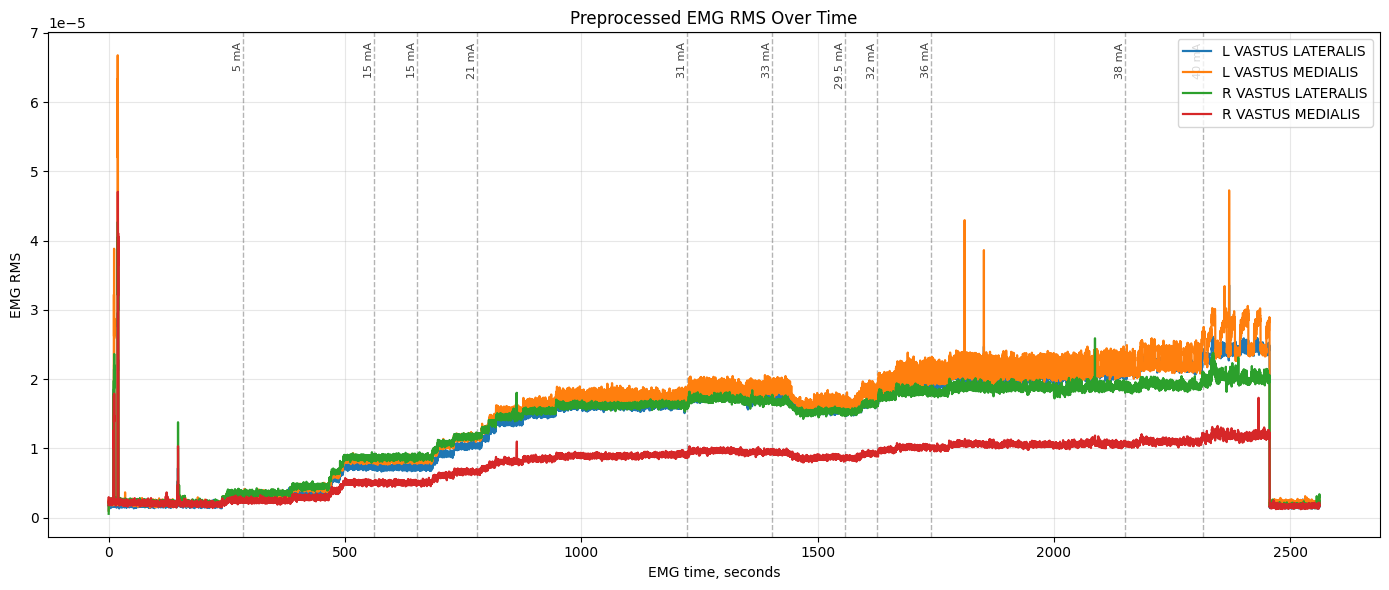

In [12]:
# EMG plotting cell

import matplotlib.pyplot as plt

emg_rms_columns = [
    column
    for column in emg_preprocessed_df.columns
    if column.endswith(" EMG RMS")
]

plt.figure(figsize=(14, 6))

for column in emg_rms_columns:
    plt.plot(
        emg_preprocessed_df["emg_time_seconds"],
        emg_preprocessed_df[column],
        label=column.replace(" EMG RMS", ""),
        linewidth=1.6,
        zorder=3,
    )

time_min = emg_preprocessed_df["emg_time_seconds"].min()
time_max = emg_preprocessed_df["emg_time_seconds"].max()
event_markers = events_df.dropna(subset=["event_seconds", "current_intensity_ma"])
event_markers = event_markers[
    event_markers["event_seconds"].between(time_min, time_max)
]

for _, event in event_markers.iterrows():
    event_time = event["event_seconds"]
    current_intensity = float(event["current_intensity_ma"])
    plt.axvline(event_time, color="0.35", linestyle="--", linewidth=1, alpha=0.45)
    plt.text(
        event_time,
        0.98,
        f"{current_intensity:g} mA",
        rotation=90,
        transform=plt.gca().get_xaxis_transform(),
        va="top",
        ha="right",
        fontsize=8,
        color="0.25",
    )

plt.xlabel("EMG time, seconds")
plt.ylabel("EMG RMS")
plt.title("Preprocessed EMG RMS Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## EMG 3D time-frequency analysis cell


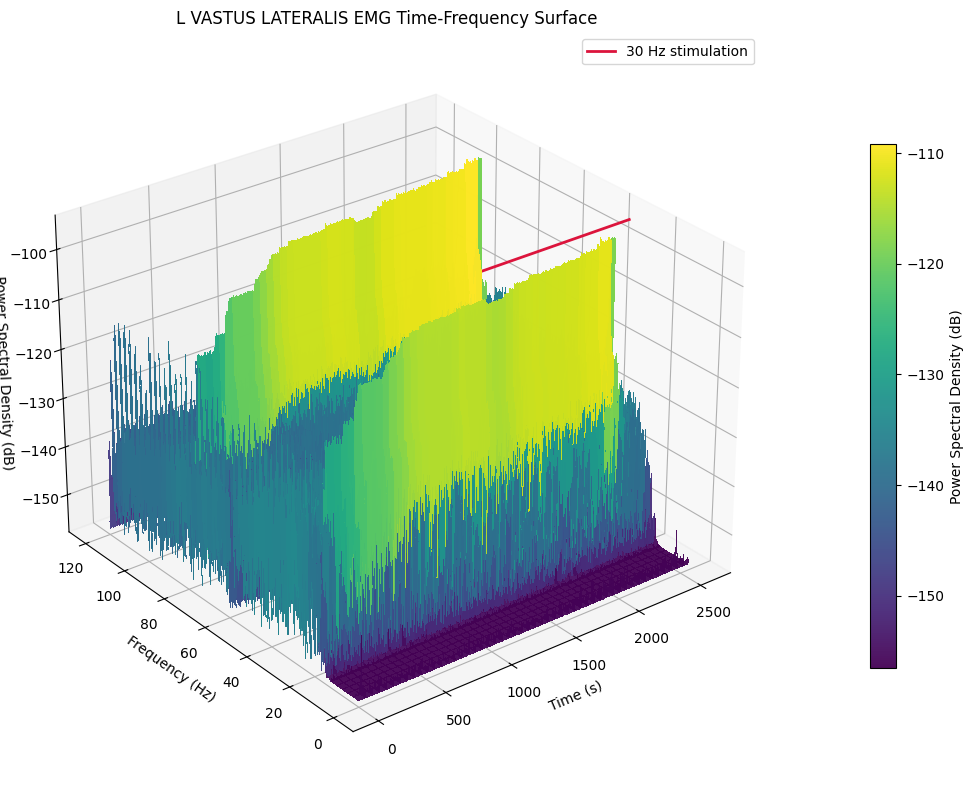

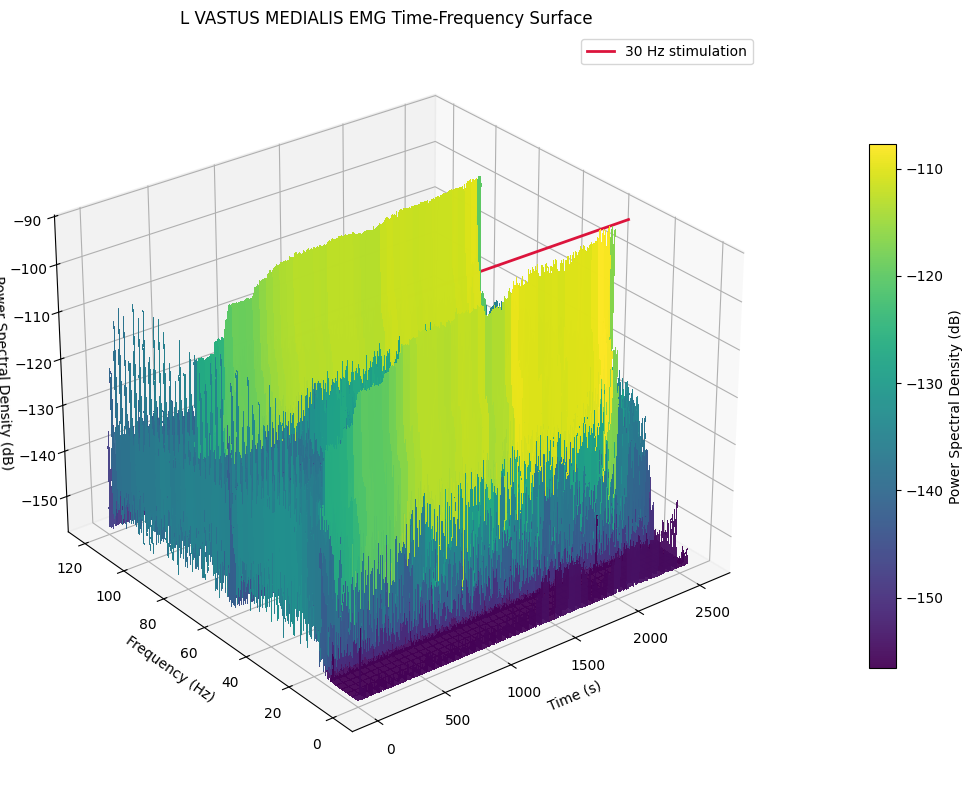

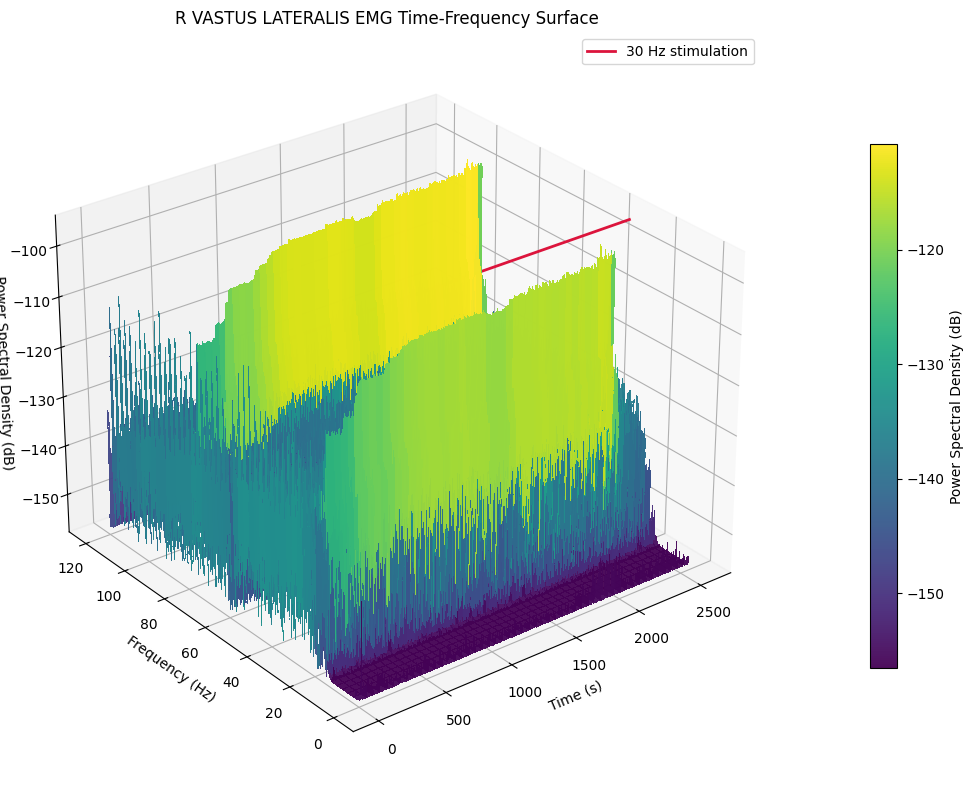

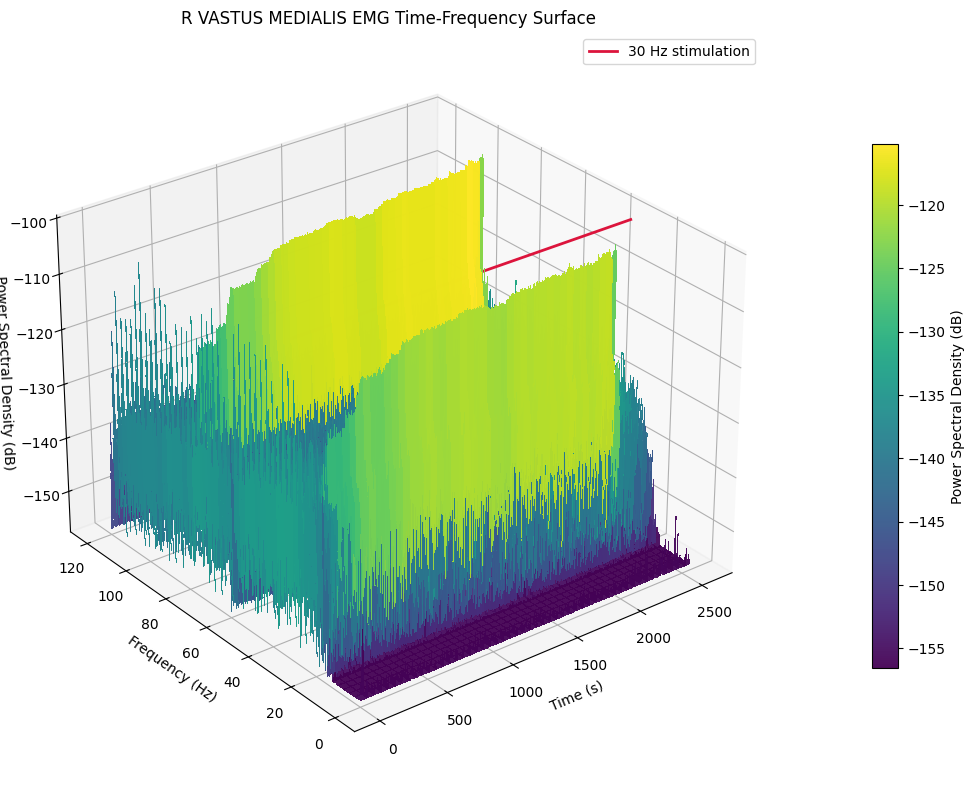

In [3]:
# EMG 3D time-frequency analysis cell

import matplotlib.pyplot as plt
from scipy.signal import spectrogram

spectrogram_max_frequency_hz = 120
stimulation_frequency_hz = 30
spectrogram_window_seconds = 2.0
spectrogram_overlap_fraction = 0.75

for sensor_name, sensor_info in emg_channels.items():
    sensor_time = pd.to_numeric(df[sensor_info["time"]], errors="coerce")
    sensor_signal = pd.to_numeric(df[sensor_info["signal"]], errors="coerce")
    valid_sensor = sensor_time.notna() & sensor_signal.notna()

    sensor_time = sensor_time[valid_sensor].reset_index(drop=True)
    sensor_signal = sensor_signal[valid_sensor].interpolate(limit_direction="both")
    sensor_fs = estimate_sample_rate_hz(sensor_time)

    centered_signal = sensor_signal - sensor_signal.mean()
    filtered_signal = bandpass_filter(
        centered_signal.to_numpy(dtype=float),
        sensor_fs,
        emg_bandpass_low_hz,
        emg_bandpass_high_hz,
    )
    filtered_signal = notch_filter_harmonics(
        filtered_signal,
        sensor_fs,
        emg_notch_base_hz,
        emg_notch_quality,
        emg_bandpass_high_hz,
    )

    nperseg = int(round(sensor_fs * spectrogram_window_seconds))
    noverlap = int(round(nperseg * spectrogram_overlap_fraction))
    frequencies, segment_times, power = spectrogram(
        filtered_signal,
        fs=sensor_fs,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="density",
        mode="psd",
    )

    frequency_mask = frequencies <= spectrogram_max_frequency_hz
    frequencies = frequencies[frequency_mask]
    power = power[frequency_mask, :]
    segment_times = segment_times + sensor_time.iloc[0]

    power_db = 10 * np.log10(power + np.finfo(float).eps)
    time_grid, frequency_grid = np.meshgrid(segment_times, frequencies)

    figure = plt.figure(figsize=(14, 8))
    axis = figure.add_subplot(111, projection="3d")
    surface = axis.plot_surface(
        time_grid,
        frequency_grid,
        power_db,
        cmap="viridis",
        linewidth=0,
        antialiased=False,
        alpha=0.95,
    )

    axis.plot(
        segment_times,
        np.full_like(segment_times, stimulation_frequency_hz),
        np.full_like(segment_times, np.nanmax(power_db)),
        color="crimson",
        linewidth=2.0,
        label="30 Hz stimulation",
    )

    axis.set_xlabel("Time (s)")
    axis.set_ylabel("Frequency (Hz)")
    axis.set_zlabel("Power Spectral Density (dB)")
    axis.set_title(f"{sensor_name} EMG Time-Frequency Surface")
    axis.view_init(elev=28, azim=-128)
    axis.legend(loc="upper right")
    figure.colorbar(surface, ax=axis, shrink=0.7, pad=0.08, label="Power Spectral Density (dB)")
    plt.tight_layout()
    plt.show()


In [2]:
# Focused L VASTUS MEDIALIS spectrogram at t = 2000 s

import matplotlib.pyplot as plt
from scipy.signal import spectrogram

analysis_time_seconds = 2000
analysis_window_seconds = 30
spectrogram_window_seconds = 1.0
spectrogram_overlap_fraction = 0.85
spectrogram_max_frequency_hz = 120
stimulation_frequency_hz = 30

sensor_info = emg_channels["L VASTUS MEDIALIS"]
sensor_time = pd.to_numeric(df[sensor_info["time"]], errors="coerce")
sensor_signal = pd.to_numeric(df[sensor_info["signal"]], errors="coerce")
valid_sensor = sensor_time.notna() & sensor_signal.notna()

sensor_time = sensor_time[valid_sensor].reset_index(drop=True)
sensor_signal = sensor_signal[valid_sensor].interpolate(limit_direction="both")
sensor_fs = estimate_sample_rate_hz(sensor_time)

half_window_seconds = analysis_window_seconds / 2
window_mask = sensor_time.between(
    analysis_time_seconds - half_window_seconds,
    analysis_time_seconds + half_window_seconds,
)

window_time = sensor_time[window_mask].reset_index(drop=True)
window_signal = sensor_signal[window_mask].reset_index(drop=True)

centered_signal = window_signal - window_signal.mean()
filtered_signal = bandpass_filter(
    centered_signal.to_numpy(dtype=float),
    sensor_fs,
    emg_bandpass_low_hz,
    emg_bandpass_high_hz,
)
filtered_signal = notch_filter_harmonics(
    filtered_signal,
    sensor_fs,
    emg_notch_base_hz,
    emg_notch_quality,
    emg_bandpass_high_hz,
)

nperseg = int(round(sensor_fs * spectrogram_window_seconds))
noverlap = int(round(nperseg * spectrogram_overlap_fraction))
frequencies, segment_times, power = spectrogram(
    filtered_signal,
    fs=sensor_fs,
    nperseg=nperseg,
    noverlap=noverlap,
    scaling="density",
    mode="psd",
)

frequency_mask = frequencies <= spectrogram_max_frequency_hz
frequencies = frequencies[frequency_mask]
power = power[frequency_mask, :]
segment_times = segment_times + window_time.iloc[0]
power_db = 10 * np.log10(power + np.finfo(float).eps)

plt.figure(figsize=(14, 6))
plt.pcolormesh(segment_times, frequencies, power_db, shading="gouraud", cmap="viridis")
# plt.axhline(stimulation_frequency_hz, color="crimson", linestyle="--", linewidth=2, label="30 Hz stimulation")
plt.colorbar(label="Power Spectral Density (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("L VASTUS MEDIALIS EMG Spectrogram Around t = 2000 s")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


NameError: name 'emg_channels' is not defined

In [32]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Settings
# --------------------------------------------------
time_col = "X[s]"
intensity_col = "current_intensity_ma"
window_seconds = 5.0

sensors = {
    "L VASTUS LATERALIS": {
        "x": "L VASTUS LATERALIS: ACC.X 1",
        "y": "L VASTUS LATERALIS: ACC.Y 1",
        "z": "L VASTUS LATERALIS: ACC.Z 1",
    },
    "L VASTUS MEDIALIS": {
        "x": "L VASTUS MEDIALIS: ACC.X 2",
        "y": "L VASTUS MEDIALIS: ACC.Y 2",
        "z": "L VASTUS MEDIALIS: ACC.Z 2",
    },
    "R VASTUS LATERALIS": {
        "x": "R VASTUS LATERALIS: ACC.X 3",
        "y": "R VASTUS LATERALIS: ACC.Y 3",
        "z": "R VASTUS LATERALIS: ACC.Z 3",
    },
    "R VASTUS MEDIALIS": {
        "x": "R VASTUS MEDIALIS: ACC.X 4",
        "y": "R VASTUS MEDIALIS: ACC.Y 4",
        "z": "R VASTUS MEDIALIS: ACC.Z 4",
    },
}

# --------------------------------------------------
# Make sure key columns are numeric
# --------------------------------------------------
df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
df[intensity_col] = pd.to_numeric(df[intensity_col], errors="coerce")

for sensor_name, cols in sensors.items():
    for axis, col in cols.items():
        df[col] = pd.to_numeric(df[col], errors="coerce")

# --------------------------------------------------
# Identify rows where stimulation intensity changes
# --------------------------------------------------
intensity = df[intensity_col]

change_mask = (
    intensity.notna()
    & intensity.ne(intensity.shift())
)

change_events = df.loc[
    change_mask,
    ["config", intensity_col, time_col]
].copy()

change_events = change_events.rename(columns={
    time_col: "event_time_s",
    intensity_col: "new_current_intensity_ma",
})

change_events["previous_current_intensity_ma"] = (
    df[intensity_col].shift().loc[change_events.index].to_numpy()
)

change_events = change_events.reset_index(names="event_row_index")

print(change_events)

   event_row_index                  config  new_current_intensity_ma  \
0           567700  DV-I | Active | Normal                       5.0   
1          1123236  DV-I | Active | Normal                      15.0   
2          1560234  DV-I | Active | Normal                      21.0   
3          2449046  DV-I | Active | Normal                      31.0   
4          2806621  DV-I | Active | Normal                      33.0   
5          3115564  DV-I | Active | Normal                      29.5   
6          3251967  DV-I | Active | Normal                      32.0   
7          3481192  DV-I | Active | Normal                      36.0   
8          4302245  DV-I | Active | Normal                      38.0   
9          4629714  DV-I | Active | Normal                      40.0   

   event_time_s  previous_current_intensity_ma  
0       283.850                            NaN  
1       561.618                            5.0  
2       780.117                           15.0  
3      1224